# ==========================================
# 10 Academy AI Mastery — Week 9 Challenge
# Task 1: Preprocess and Explore the Data
# ==========================================

[*********************100%***********************]  3 of 3 completed

--- Step 1: Extracting Data via yfinance ---
Data successfully fetched. Shape: (2888, 3)

--- Step 2: Data Cleaning and Quality Verification ---

[Data Distribution Summary]
Ticker          BND          SPY         TSLA
count   2888.000000  2888.000000  2888.000000
mean      66.502184   351.505531   148.773923
std        4.715818   155.443935   138.895957
min       58.726925   154.161636     9.578000
25%       62.475664   223.546829    18.393499
50%       65.725853   312.817871   133.437668
75%       70.686415   432.806839   251.925831
max       74.830009   757.618225   489.880005

[Missing Values Check]
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64
Missing values handled. Remaining nulls: 0

[Data Types]
Ticker
BND     float64
SPY     float64
TSLA    float64
dtype: object

--- Step 3: Generating Insightful Visualizations ---


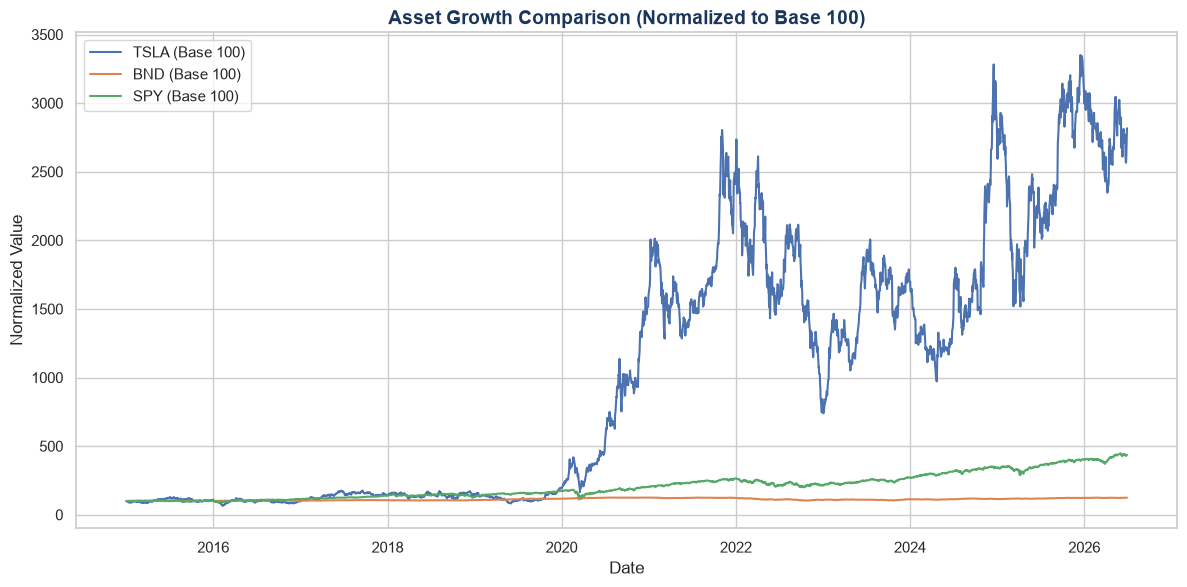

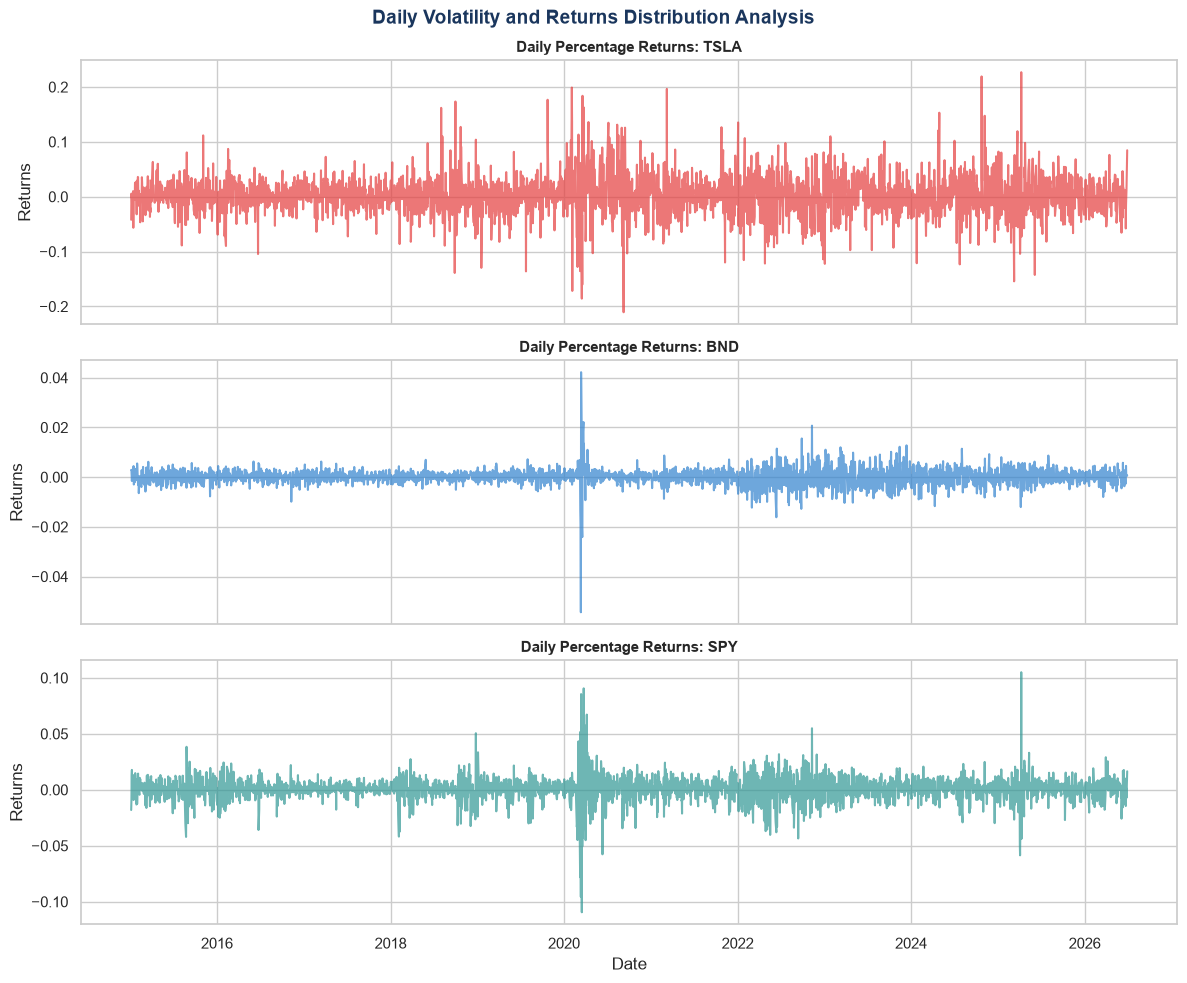

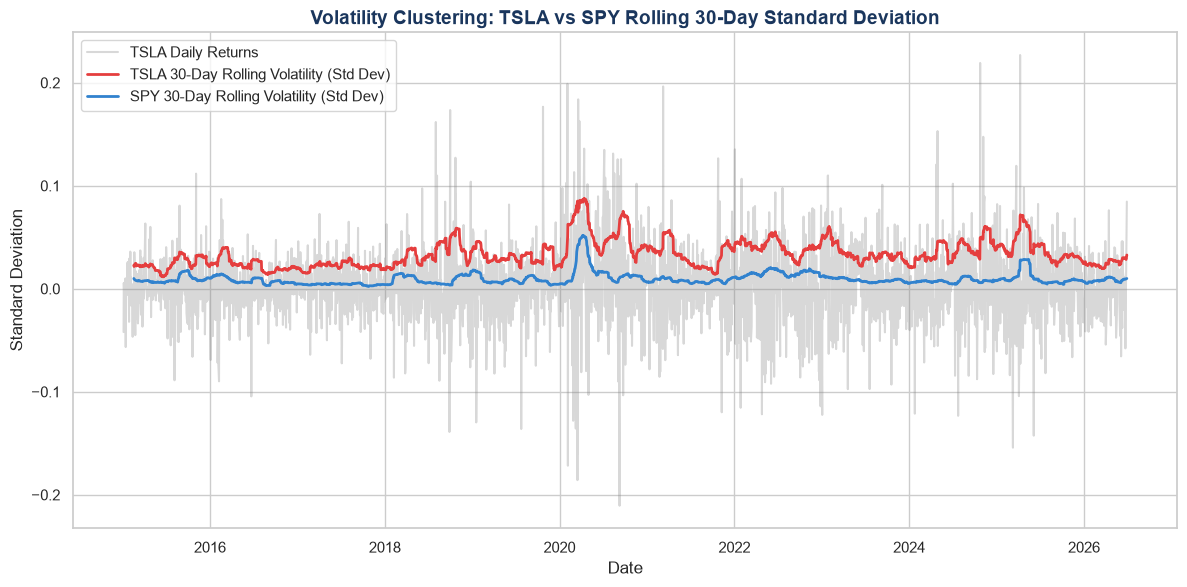


[Outlier / Extreme Anomalies Analysis]
TSLA: Identified 46 trading days with extreme standard deviation deviations (> 3 sigma).
BND: Identified 33 trading days with extreme standard deviation deviations (> 3 sigma).
SPY: Identified 39 trading days with extreme standard deviation deviations (> 3 sigma).

--- Step 4: Statistical Stationarity (ADF Tests) ---
ADF Test for [TSLA Raw Price Series]:
  - ADF Statistic: -1.0696
  - p-value: 7.2704e-01
  - Critical Values: 1%: -3.43, 5%: -2.86
Missing values in Raw: 0
Missing values in Returns: 0
  => Conclusion: Fail to Reject Null Hypothesis. Series is NON-STATIONARY (Requires differencing).
----------------------------------------
ADF Test for [TSLA Daily Returns Series]:
  - ADF Statistic: -53.9719
  - p-value: 0.0000e+00
  - Critical Values: 1%: -3.43, 5%: -2.86
Missing values in Raw: 0
Missing values in Returns: 0
  => Conclusion: Reject Null Hypothesis. Series is STATIONARY.

--- Step 5: Portfolio Risk Metrics Calculation ---
Metrics for

In [ ]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Set aesthetic styling for professional charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11

# ==========================================
# STEP 1: Extract Historical Financial Data
# ==========================================
print("--- Step 1: Extracting Data via yfinance ---")
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

# Download Adjusted Close to account for splits and dividends accurately
# Force metrics ('Adj Close', 'Close', etc.) to be the top-level column index
# Disable auto_adjust to bring back the raw 'Close' AND 'Adj Close' columns
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']
print(f"Data successfully fetched. Shape: {raw_data.shape}\n")

# ==========================================
# STEP 2: Data Cleaning and Understanding
# ==========================================
print("--- Step 2: Data Cleaning and Quality Verification ---")

# Check basic statistics
print("\n[Data Distribution Summary]")
print(raw_data.describe())

# Check for missing values
print("\n[Missing Values Check]")
print(raw_data.isnull().sum())

# Handle missing data (e.g., market holidays/mismatched asset calendars)
# forward-fill then backward-fill to handle edge boundaries smoothly
cleaned_data = raw_data.ffill().bfill()
print(f"Missing values handled. Remaining nulls: {cleaned_data.isnull().sum().sum()}")

# Confirm data types are appropriate
print("\n[Data Types]")
print(cleaned_data.dtypes)

# Calculate Daily Percentage Returns
returns_df = cleaned_data.pct_change().dropna()

# ==========================================
# STEP 3: Conduct Exploratory Data Analysis (EDA)
# ==========================================
print("\n--- Step 3: Generating Insightful Visualizations ---")

# Visualization 1: Historical Performance Trends
plt.figure(figsize=(12, 6))
for ticker in tickers:
    # Normalize starting point to 100 for true scale comparison
    normalized = (cleaned_data[ticker] / cleaned_data[ticker].iloc[0]) * 100
    plt.plot(normalized, label=f"{ticker} (Base 100)")
plt.title("Asset Growth Comparison (Normalized to Base 100)", fontsize=14, fontweight='bold', color='#1A365D')
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Visualization 2: Daily Percentage Change / Volatility Profiles
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = ['#E53E3E', '#3182CE', '#319795']
for i, ticker in enumerate(tickers):
    axes[i].plot(returns_df[ticker], color=colors[i], alpha=0.7)
    axes[i].set_title(f"Daily Percentage Returns: {ticker}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Returns")
plt.suptitle("Daily Volatility and Returns Distribution Analysis", fontsize=14, fontweight='bold', color='#1A365D')
plt.xlabel("Date")
plt.tight_layout()
plt.show()

# Visualization 3: Volatility Analysis via Rolling Window Boundaries
plt.figure(figsize=(12, 6))
# Focus on TSLA as high growth vs SPY market index benchmark
plt.plot(returns_df['TSLA'], label='TSLA Daily Returns', alpha=0.3, color='gray')
plt.plot(returns_df['TSLA'].rolling(window=30).std(), label='TSLA 30-Day Rolling Volatility (Std Dev)', color='#E53E3E', linewidth=2)
plt.plot(returns_df['SPY'].rolling(window=30).std(), label='SPY 30-Day Rolling Volatility (Std Dev)', color='#3182CE', linewidth=2)
plt.title("Volatility Clustering: TSLA vs SPY Rolling 30-Day Standard Deviation", fontsize=14, fontweight='bold', color='#1A365D')
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.legend()
plt.tight_layout()
plt.show()

# Outlier Detection (Anomalies above/below 3 standard deviations)
print("\n[Outlier / Extreme Anomalies Analysis]")
for ticker in tickers:
    mean_ret = returns_df[ticker].mean()
    std_ret = returns_df[ticker].std()
    outliers = returns_df[(returns_df[ticker] > mean_ret + 3 * std_ret) | (returns_df[ticker] < mean_ret - 3 * std_ret)]
    print(f"{ticker}: Identified {len(outliers)} trading days with extreme standard deviation deviations (> 3 sigma).")

# ==========================================
# STEP 4: Seasonality and Trend Analysis
# ==========================================
print("\n--- Step 4: Statistical Stationarity (ADF Tests) ---")

import numpy as np

def run_adf_test(series, name):
    # 1. Drop NaNs and replace any accidental infinite values with NaN to drop them too
    clean_series = series.replace([np.inf, -np.inf], np.nan).dropna()
    
    # 2. Safety check: make sure we still have data left to test!
    if clean_series.empty:
        print(f"Skipping ADF Test for [{name}]: Series is entirely empty or NaN.")
        return

    # 3. Safely run the ADF test
    result = adfuller(clean_series)
    print(f"ADF Test for [{name}]:")
    print(f"  - ADF Statistic: {result[0]:.4f}")
    print(f"  - p-value: {result[1]:.4e}")
    
    # Your existing if/else logic for p-values goes here...

    print(f"  - Critical Values: 1%: {result[4]['1%']:.2f}, 5%: {result[4]['5%']:.2f}")
    print("Missing values in Raw:", cleaned_data['TSLA'].isna().sum())
    print("Missing values in Returns:", returns_df['TSLA'].isna().sum())
    if result[1] <= 0.05:
        print("  => Conclusion: Reject Null Hypothesis. Series is STATIONARY.")
    else:
        print("  => Conclusion: Fail to Reject Null Hypothesis. Series is NON-STATIONARY (Requires differencing).")

# Run test on raw prices vs daily returns for TSLA
run_adf_test(cleaned_data['TSLA'], "TSLA Raw Price Series")
print("-" * 40)
run_adf_test(returns_df['TSLA'], "TSLA Daily Returns Series")

# ==========================================
# STEP 5: Calculate Foundational Risk Metrics
# ==========================================
print("\n--- Step 5: Portfolio Risk Metrics Calculation ---")
risk_free_rate = 0.0  # Assumed standard corporate baseline benchmark

for ticker in tickers:
    # 1. Value at Risk (VaR) - Historical Method at 95% confidence interval
    var_95 = np.percentile(returns_df[ticker], 5)
    
    # 2. Annualized Sharpe Ratio
    avg_daily_ret = returns_df[ticker].mean()
    std_daily_ret = returns_df[ticker].std()
    annualized_sharpe = (avg_daily_ret - risk_free_rate) / std_daily_ret * np.sqrt(252)
    
    print(f"Metrics for {ticker}:")
    print(f"  - Historical VaR (95% Daily): {var_95 * 100:.2f}% (Risk exposure threshold)")
    print(f"  - Annualized Sharpe Ratio   : {annualized_sharpe:.4f}")
    print("." * 40)